# Plotting a graph over time of the affilitions

In [14]:
import pandas as pd
import numpy as np
melted_master_condenced = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/AER_Melted_Weights_applied.xlsx') 
print(melted_master_condenced.shape)
melted_master_condenced = melted_master_condenced[['Article_ID','Weight','Affiliation','year']]
melted_master_condenced = melted_master_condenced.reset_index(drop=True)
melted_master_condenced = melted_master_condenced.replace('University Of Wisconsin-Madison', 'University Of Wisconsin')

(15282, 7)


In [15]:
melted_master_condenced['decade'] = ''
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1940) & (melted_master_condenced['year'] < 1950), '[1940,1949]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1950) & (melted_master_condenced['year'] < 1960), '[1950,1959]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1960) & (melted_master_condenced['year'] < 1970), '[1960,1969]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1970) & (melted_master_condenced['year'] < 1980), '[1970,1979]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1980) & (melted_master_condenced['year'] < 1990), '[1980,1989]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1990) & (melted_master_condenced['year'] < 2000), '[1990,1999]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 2000) & (melted_master_condenced['year'] < 2011), '[2000,2010]', melted_master_condenced['decade'])
print(melted_master_condenced.head())
print(melted_master_condenced.tail())

   Article_ID  Weight                Affiliation  year       decade
0     1805065     0.5    University Of Minnesota  1940  [1940,1949]
1     1807585     1.0  Michigan State University  1940  [1940,1949]
2     1807586     1.0      Ohio State University  1940  [1940,1949]
3     1807587     1.0           Brown University  1940  [1940,1949]
4     1807588     1.0   University Of California  1940  [1940,1949]
       Article_ID    Weight                         Affiliation  year  \
15277    27805004  0.333333                University Of Galway  2010   
15278    27805005  0.333333  Saint Mary'S College Of California  2010   
15279    27805006  0.333333      Indiana University Bloomington  2010   
15280    27804997  0.100000              University Of Michigan  2010   
15281    41038751  1.000000              University Of Maryland  2010   

            decade  
15277  [2000,2010]  
15278  [2000,2010]  
15279  [2000,2010]  
15280  [2000,2010]  
15281  [2000,2010]  


# Ranking the Universities based on their number of papers per published per decade

In [16]:
#Gets the top 10 overall
melted_master_condenced = melted_master_condenced.sort_values(by=['year'])
melted_master_condenced['aff_cum_sum'] = melted_master_condenced.groupby(['Affiliation'])['Weight'].cumsum()

mask_journal = melted_master_condenced['Affiliation'].isin(['National Bureau Of Economic Research'])
melted_master_condenced = melted_master_condenced[~mask_journal]

highest_vals = melted_master_condenced.drop_duplicates(subset = ['Affiliation'], keep = 'last')
highest_vals_10 = highest_vals.nlargest(25,'aff_cum_sum')
print(highest_vals_10.shape)
#print(highest_vals_10.head())
print(highest_vals_10.iat[6,2])

melted_master_condenced_decade = melted_master_condenced[['Article_ID','Weight','Affiliation','decade']]

a = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[6,2]]
a['aff_cum_counts_yearly'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
a = a.drop_duplicates(subset = ['decade'], keep = 'last')
print(a.head())
print(a.shape)

(25, 6)
Yale University
      Article_ID  Weight      Affiliation       decade  aff_cum_counts_yearly
951      1831734     1.0  Yale University  [1940,1949]              21.500000
1823     1813078     1.0  Yale University  [1950,1959]              26.035714
2925     1823692     0.5  Yale University  [1960,1969]              43.116667
5059     1801622     1.0  Yale University  [1970,1979]              48.583333
7717     1804778     0.5  Yale University  [1980,1989]              39.500000
(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_20201/1670870116.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['aff_cum_counts_yearly'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()


In [17]:
a = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[0,2]]
a['aff_cum_sum_decade'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
a = a.drop_duplicates(subset = ['decade'], keep = 'last')
print(a.shape)

b = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[1,2]]
b['aff_cum_sum_decade'] = b.groupby(['Affiliation','decade'])['Weight'].cumsum()
b = b.drop_duplicates(subset = ['decade'], keep = 'last')
print(b.shape)

c = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[2,2]]
c['aff_cum_sum_decade'] = c.groupby(['Affiliation','decade'])['Weight'].cumsum()
c = c.drop_duplicates(subset = ['decade'], keep = 'last')
print(c.shape)

d = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[3,2]]
d['aff_cum_sum_decade'] = d.groupby(['Affiliation','decade'])['Weight'].cumsum()
d = d.drop_duplicates(subset = ['decade'], keep = 'last')
print(d.shape)

e = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[4,2]]
e['aff_cum_sum_decade'] = e.groupby(['Affiliation','decade'])['Weight'].cumsum()
e = e.drop_duplicates(subset = ['decade'], keep = 'last')
print(e.shape)

f = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[5,2]]
f['aff_cum_sum_decade'] = f.groupby(['Affiliation','decade'])['Weight'].cumsum()
f = f.drop_duplicates(subset = ['decade'], keep = 'last')
print(f.shape)

g = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[6,2]]
g['aff_cum_sum_decade'] = g.groupby(['Affiliation','decade'])['Weight'].cumsum()
g = g.drop_duplicates(subset = ['decade'], keep = 'last')
print(g.shape)

h = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[7,2]]
h['aff_cum_sum_decade'] = h.groupby(['Affiliation','decade'])['Weight'].cumsum()
h = h.drop_duplicates(subset = ['decade'], keep = 'last')
print(h.shape)

i = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[8,2]]
i['aff_cum_sum_decade'] = i.groupby(['Affiliation','decade'])['Weight'].cumsum()
i = i.drop_duplicates(subset = ['decade'], keep = 'last')
print(i.shape)

j = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[9,2]]
j['aff_cum_sum_decade'] = j.groupby(['Affiliation','decade'])['Weight'].cumsum()
j = j.drop_duplicates(subset = ['decade'], keep = 'last')
print(j.shape)

k = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[10,2]]
k['aff_cum_sum_decade'] = k.groupby(['Affiliation','decade'])['Weight'].cumsum()
k = k.drop_duplicates(subset = ['decade'], keep = 'last')
print(k.shape)

l = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[11,2]]
l['aff_cum_sum_decade'] = l.groupby(['Affiliation','decade'])['Weight'].cumsum()
l = l.drop_duplicates(subset = ['decade'], keep = 'last')
print(l.shape)

m = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[12,2]]
m['aff_cum_sum_decade'] = m.groupby(['Affiliation','decade'])['Weight'].cumsum()
m = m.drop_duplicates(subset = ['decade'], keep = 'last')
print(m.shape)

n = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[13,2]]
n['aff_cum_sum_decade'] = n.groupby(['Affiliation','decade'])['Weight'].cumsum()
n = n.drop_duplicates(subset = ['decade'], keep = 'last')
print(n.shape)

o = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[14,2]]
o['aff_cum_sum_decade'] = o.groupby(['Affiliation','decade'])['Weight'].cumsum()
o = o.drop_duplicates(subset = ['decade'], keep = 'last')
print(o.shape)

p = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[15,2]]
p['aff_cum_sum_decade'] = p.groupby(['Affiliation','decade'])['Weight'].cumsum()
p = p.drop_duplicates(subset = ['decade'], keep = 'last')
print(p.shape)

q = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[16,2]]
q['aff_cum_sum_decade'] = q.groupby(['Affiliation','decade'])['Weight'].cumsum()
q = q.drop_duplicates(subset = ['decade'], keep = 'last')
print(q.shape)

r = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[17,2]]
r['aff_cum_sum_decade'] = r.groupby(['Affiliation','decade'])['Weight'].cumsum()
r = r.drop_duplicates(subset = ['decade'], keep = 'last')
print(r.shape)

s = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[18,2]]
s['aff_cum_sum_decade'] = s.groupby(['Affiliation','decade'])['Weight'].cumsum()
s = s.drop_duplicates(subset = ['decade'], keep = 'last')
print(s.shape)

t = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[19,2]]
t['aff_cum_sum_decade'] = t.groupby(['Affiliation','decade'])['Weight'].cumsum()
t = t.drop_duplicates(subset = ['decade'], keep = 'last')
print(t.shape)

u = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[20,2]]
u['aff_cum_sum_decade'] = u.groupby(['Affiliation','decade'])['Weight'].cumsum()
u = u.drop_duplicates(subset = ['decade'], keep = 'last')
print(u.shape)

v = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[21,2]]
v['aff_cum_sum_decade'] = v.groupby(['Affiliation','decade'])['Weight'].cumsum()
v = v.drop_duplicates(subset = ['decade'], keep = 'last')
print(v.shape)

w = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[22,2]]
w['aff_cum_sum_decade'] = w.groupby(['Affiliation','decade'])['Weight'].cumsum()
w = w.drop_duplicates(subset = ['decade'], keep = 'last')
print(w.shape)

x = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[23,2]]
x['aff_cum_sum_decade'] = x.groupby(['Affiliation','decade'])['Weight'].cumsum()
x = x.drop_duplicates(subset = ['decade'], keep = 'last')
print(x.shape)

y = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[24,2]]
y['aff_cum_sum_decade'] = y.groupby(['Affiliation','decade'])['Weight'].cumsum()
y = y.drop_duplicates(subset = ['decade'], keep = 'last')
print(y.shape)

(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_20201/1100585584.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['aff_cum_sum_decade'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_20201/1100585584.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b['aff_cum_sum_decade'] = b.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_20201/1100585584.py:12: SettingWith

/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_20201/1100585584.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  l['aff_cum_sum_decade'] = l.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_20201/1100585584.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  m['aff_cum_sum_decade'] = m.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_20201/1100585584.py:67: SettingWi

(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_20201/1100585584.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  o['aff_cum_sum_decade'] = o.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_20201/1100585584.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p['aff_cum_sum_decade'] = p.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_20201/1100585584.py:82: SettingWi

In [18]:
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j], axis=0)
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o], axis=0)
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t], axis=0)
ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t,u,v,w,x,y], axis=0)
ranked = ranked.sort_values(by=['decade','Affiliation'])
print(ranked.shape)

ranked['Rank'] = ranked.groupby(['decade'])['aff_cum_sum_decade'].rank(method = 'max', ascending= False)
print(ranked.shape)
print(ranked.tail(20))
#ranked.to_excel('/Users/MattJohnson/Desktop/Affiliations/2_Extracting affilitations/2_Fuzzy matching/Combined journals/Combined journal yearly rank.xlsx') 

(175, 5)
(175, 6)
       Article_ID    Weight                                     Affiliation  \
14888    27871281  0.166667                              Cornell University   
14938    27805055  0.166667                                 Duke University   
14921    27871269  0.500000                              Harvard University   
14920    41038765  0.500000  London School Of Economics & Political Science   
14917    27805053  0.500000           Massachusetts Institute Of Technology   
14940    41038756  1.000000                             New York University   
14924    41038761  1.000000                         Northwestern University   
14950    27804935  1.000000                            Princeton University   
15017    27805062  0.500000                             Stanford University   
14933    41038752  0.166667              University Of California, Berkeley   
15208    27804965  0.500000           University Of California, Los Angeles   
14936    27805057  0.250000       

In [19]:
#ranked.to_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.3/JPE_Ranked_data.xlsx') 

In [20]:
ranked = ranked.rename(columns={"decade": "Year Bucket"})
ranked

,Article_ID,Weight,Affiliation,Year Bucket,aff_cum_sum_decade,Rank
940,1816600,1.000000,Board Of Governors Of The Federal Reserve System,"[1940,1949]",20.333333,5.0
831,1821171,0.166667,Brookings Institution,"[1940,1949]",13.791667,9.0
719,1802670,1.000000,Brown University,"[1940,1949]",6.000000,19.0
937,1816597,1.000000,Carnegie Mellon University,"[1940,1949]",5.500000,21.0
947,1810488,1.000000,Columbia University,"[1940,1949]",30.550000,3.0
...,...,...,...,...,...,...
14886,27871279,0.333333,University Of Pennsylvania,"[2000,2010]",41.525000,8.0
15232,27871233,0.500000,University Of Virginia,"[2000,2010]",12.083333,23.0
14833,27804999,0.500000,University Of Washington,"[2000,2010]",2.000000,25.0
14934,27805059,0.500000,University Of Wisconsin,"[2000,2010]",18.083333,17.0


In [21]:
pivot = ranked.pivot(index='Year Bucket', columns='Affiliation', values='Rank')
pivot

Affiliation,Board Of Governors Of The Federal Reserve System,Brookings Institution,Brown University,Carnegie Mellon University,Columbia University,Cornell University,Duke University,Harvard University,London School Of Economics & Political Science,Massachusetts Institute Of Technology,...,"University Of California, Los Angeles",University Of Chicago,University Of Maryland,University Of Michigan,University Of Minnesota,University Of Pennsylvania,University Of Virginia,University Of Washington,University Of Wisconsin,Yale University
Year Bucket,,,,,,,,,,,,,,,,,,,,,
"[1940,1949]",5.0,9.0,19.0,21.0,3.0,20.0,10.0,1.0,25.0,11.0,...,23.0,2.0,24.0,15.0,7.0,13.0,18.0,16.0,14.0,4.0
"[1950,1959]",14.0,17.0,24.0,21.0,3.0,22.0,16.0,1.0,23.0,6.0,...,9.0,3.0,21.0,8.0,19.0,12.0,16.0,18.0,13.0,5.0
"[1960,1969]",21.0,16.0,17.0,13.0,10.0,14.0,23.0,5.0,23.0,4.0,...,12.0,1.0,24.0,9.0,20.0,8.0,18.0,15.0,12.0,2.0
"[1970,1979]",16.0,15.0,17.0,20.0,13.0,19.0,23.0,1.0,25.0,5.0,...,12.0,2.0,18.0,8.0,14.0,6.0,24.0,21.0,4.0,3.0
"[1980,1989]",25.0,12.0,23.0,21.0,16.0,24.0,20.0,1.0,23.0,3.0,...,9.0,4.0,14.0,10.0,17.0,6.0,19.0,19.0,15.0,8.0
"[1990,1999]",13.0,25.0,22.0,21.0,6.0,18.0,15.0,1.0,20.0,3.0,...,12.0,4.0,14.0,11.0,23.0,10.0,19.0,24.0,17.0,9.0
"[2000,2010]",16.0,24.0,21.0,19.0,7.0,22.0,18.0,1.0,14.0,5.0,...,13.0,4.0,15.0,12.0,20.0,8.0,23.0,25.0,17.0,10.0


In [22]:
pivot_ordered = pivot[['University Of Chicago','Massachusetts Institute Of Technology','Harvard University','University Of Pennsylvania','Northwestern University','Princeton University','Stanford University','Columbia University', 'University Of California, Los Angeles','Yale University']]
pivot_ordered

Affiliation,University Of Chicago,Massachusetts Institute Of Technology,Harvard University,University Of Pennsylvania,Northwestern University,Princeton University,Stanford University,Columbia University,"University Of California, Los Angeles",Yale University
Year Bucket,,,,,,,,,,
"[1940,1949]",2.0,11.0,1.0,13.0,22.0,6.0,8.0,3.0,23.0,4.0
"[1950,1959]",3.0,6.0,1.0,12.0,10.0,11.0,4.0,3.0,9.0,5.0
"[1960,1969]",1.0,4.0,5.0,8.0,19.0,6.0,7.0,10.0,12.0,2.0
"[1970,1979]",2.0,5.0,1.0,6.0,11.0,10.0,7.0,13.0,12.0,3.0
"[1980,1989]",4.0,3.0,1.0,6.0,11.0,2.0,5.0,16.0,9.0,8.0
"[1990,1999]",4.0,3.0,1.0,10.0,8.0,7.0,2.0,6.0,12.0,9.0
"[2000,2010]",4.0,5.0,1.0,8.0,9.0,6.0,2.0,7.0,13.0,10.0


In [23]:
ranked['aff_cum_sum_decade'] = ranked['aff_cum_sum_decade'].apply(lambda x: round(x, 1))
pivot2 = ranked.pivot(index='Year Bucket', columns='Affiliation', values='aff_cum_sum_decade')
pivot2_ordered = pivot2[['University Of Chicago','Massachusetts Institute Of Technology','Harvard University','University Of Pennsylvania','Northwestern University','Princeton University','Stanford University','Columbia University', 'University Of California, Los Angeles','Yale University']]

pivot2_ordered

Affiliation,University Of Chicago,Massachusetts Institute Of Technology,Harvard University,University Of Pennsylvania,Northwestern University,Princeton University,Stanford University,Columbia University,"University Of California, Los Angeles",Yale University
Year Bucket,,,,,,,,,,
"[1940,1949]",32.2,13.0,55.2,12.5,5.0,17.5,14.0,30.6,5.0,21.5
"[1950,1959]",33.2,23.7,46.0,15.3,19.5,16.2,29.2,33.2,20.2,26.0
"[1960,1969]",43.4,41.1,40.0,29.0,11.1,34.2,29.2,24.9,23.0,43.1
"[1970,1979]",50.2,37.2,67.7,36.8,27.5,33.3,36.6,22.0,26.2,48.6
"[1980,1989]",52.3,64.7,79.5,47.6,27.6,65.2,52.2,20.4,29.3,39.5
"[1990,1999]",49.3,56.5,98.5,36.6,39.4,42.2,61.8,44.9,29.1,39.0
"[2000,2010]",82.7,68.9,132.6,41.5,38.2,62.3,85.2,53.6,32.6,37.0


In [27]:

invert_pivot = ranked.pivot(index='Affiliation', columns='Year Bucket', values='aff_cum_sum_decade')

invert_pivot['Total papers'] = invert_pivot.sum(axis=1)
invert_pivot['Average Paper per decade'] = invert_pivot.mean(axis=1)
invert_pivot['Total papers'] = invert_pivot['Total papers'].astype(int)
invert_pivot['Average Paper per decade'] = invert_pivot['Average Paper per decade'].astype(int)

invert_pivot['[1940,1949]'] = invert_pivot['[1940,1949]'].fillna(0).astype(int)
invert_pivot['[1950,1959]'] = invert_pivot['[1950,1959]'].fillna(0).astype(int)
invert_pivot['[1960,1969]'] = invert_pivot['[1960,1969]'].fillna(0).astype(int)
invert_pivot['[1970,1979]'] = invert_pivot['[1970,1979]'].fillna(0).astype(int)
invert_pivot['[1980,1989]'] = invert_pivot['[1980,1989]'].fillna(0).astype(int)
invert_pivot['[1990,1999]'] = invert_pivot['[1990,1999]'].fillna(0).astype(int)
invert_pivot['[2000,2010]'] = invert_pivot['[2000,2010]'].fillna(0).astype(int)

invert_pivot = invert_pivot.sort_values(by='Total papers', ascending=False)
#invert_pivot = invert_pivot.reset_index(drop=True)
#invert_pivot = invert_pivot.drop('Year Bucket', axis=1)
invert_pivot
invert_pivot.to_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.3. Rankings per decade/AER pivot.xlsx') 
invert_pivot

Year Bucket,"[1940,1949]","[1950,1959]","[1960,1969]","[1970,1979]","[1980,1989]","[1990,1999]","[2000,2010]",Total papers,Average Paper per decade
Affiliation,,,,,,,,,
Harvard University,55,46,40,67,79,98,132,519,129
University Of Chicago,32,33,43,50,52,49,82,343,85
Stanford University,14,29,29,36,52,61,85,308,77
Massachusetts Institute Of Technology,13,23,41,37,64,56,68,305,76
"University Of California, Berkeley",12,23,42,34,40,46,84,284,71
Princeton University,17,16,34,33,65,42,62,270,67
Yale University,21,26,43,48,39,39,37,254,63
Columbia University,30,33,24,22,20,44,53,229,57
University Of Pennsylvania,12,15,29,36,47,36,41,219,54


<AxesSubplot: xlabel='Year Bucket', ylabel='Affiliation'>

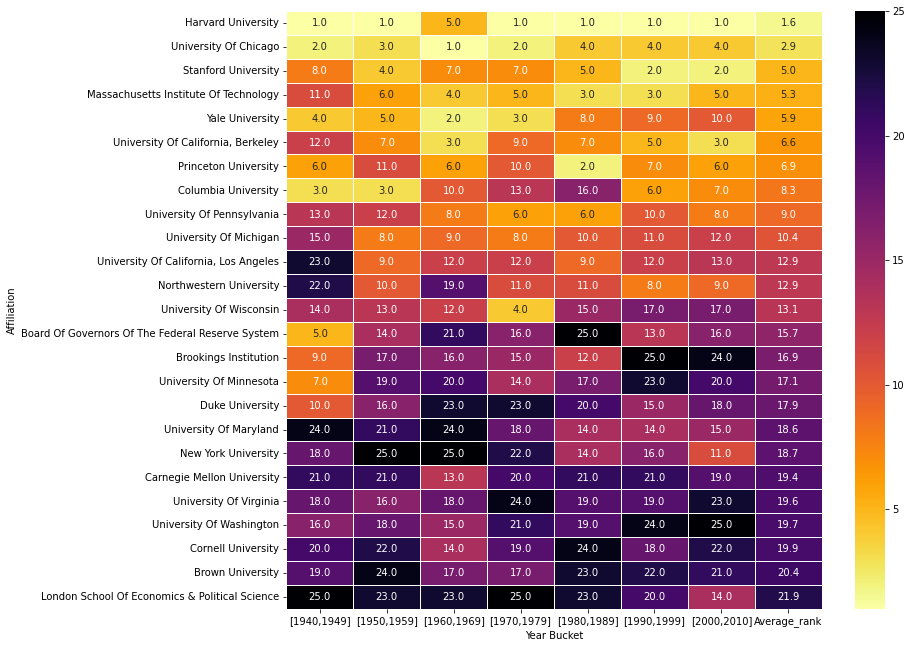

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt


ranked = ranked.replace(0, '')
invert_pivot = ranked.pivot(index='Affiliation', columns='Year Bucket', values='Rank')
invert_pivot['Average_rank'] = invert_pivot.mean(axis=1)

invert_pivot = invert_pivot.sort_values(by='Average_rank', ascending=True)


f, ax = plt.subplots(figsize=(12, 11))
cmap = plt.get_cmap('inferno_r')
sns.heatmap(invert_pivot, annot=True, fmt=".1f", cmap = cmap, linewidths=.5, ax=ax)

Year Bucket                                       [1940,1949]  [1950,1959]  \
Affiliation                                                                  
Board Of Governors Of The Federal Reserve System         20.3         11.5   
Brookings Institution                                    13.8          8.9   
Brown University                                          6.0          3.0   
Carnegie Mellon University                                5.5          5.5   
Columbia University                                      30.6         33.2   
Cornell University                                        5.6          4.5   
Duke University                                          13.1         11.0   
Harvard University                                       55.2         46.0   
London School Of Economics & Political Science            2.5          3.5   
Massachusetts Institute Of Technology                    13.0         23.7   
New York University                                       7.5   

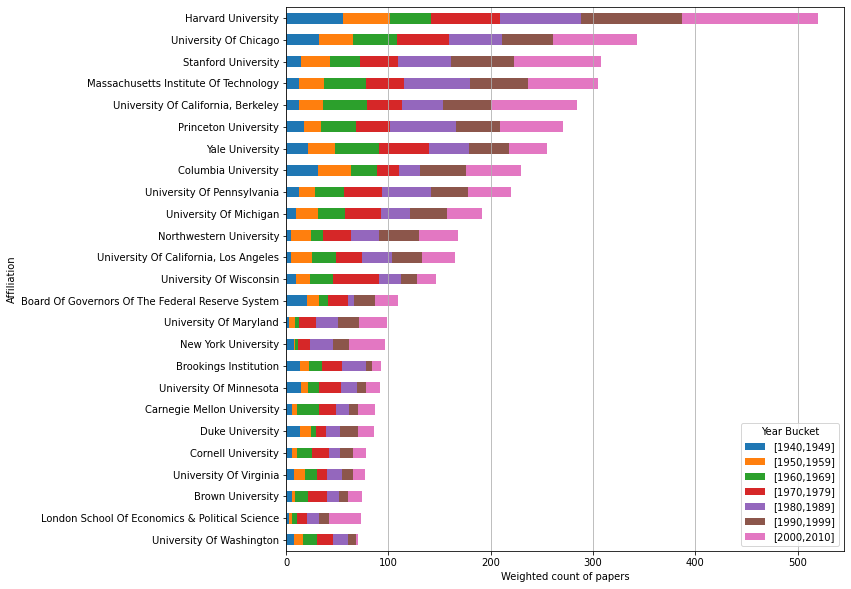

In [26]:
p = ranked.pivot(index='Affiliation', columns='Year Bucket', values='aff_cum_sum_decade')
print(p)
p['sum_cols'] = p.sum(axis=1)
p = p.sort_values(by='sum_cols', ascending=True)
p = p.drop(['sum_cols'], axis=1)

ax = p.plot.barh(stacked=True, figsize=(10, 10))
#plt.xticks(np.arange(0, 375, step=25))
plt.xlabel('Weighted count of papers')
plt.grid(axis = 'x')
plt.show()
